In [2]:
import os

# This guide can only be run with the torch backend.
os.environ["KERAS_BACKEND"] = "torch"

import torch
import keras
from keras import layers
import numpy as np
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from keras import layers
from keras import models
from IPython import display
import scipy.io.wavfile
import librosa.display

I0000 00:00:1774298298.402730   68379 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774298299.779165   68379 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
FILE="/home/ahmed/workspace/kfupm/ics504/project/datasets/surprised/03-01-08-01-01-01-01_fixed_fixed.wav"

In [4]:
try:
    with open(FILE, 'r') as f:
        print('file exists')
        pass
except FileNotFoundError:
    print('file missing')
    pass

file exists


In [5]:
#/home/ahmed/workspace/kfupm/ics504/project/datasets/surprised/03-01-08-01-01-01-01_fixed.wav
#/home/ahmed/workspace/kfupm/ics504/project/datasets/pleasant_surprised/OAF_back_ps.wav
sample_rate, data = scipy.io.wavfile.read(FILE)
print(sample_rate)
print(data)
data = data.astype(np.float64)

16000
[ 0 -1  0 ...  0 -1  0]


In [6]:
audio_binary = tf.io.read_file(FILE)
audio, _ = tf.audio.decode_wav(audio_binary)

W0000 00:00:1774298345.558235   68379 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1774298345.564838   68379 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1774298345.743760   68379 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.


/home/ahmed/workspace/kfupm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


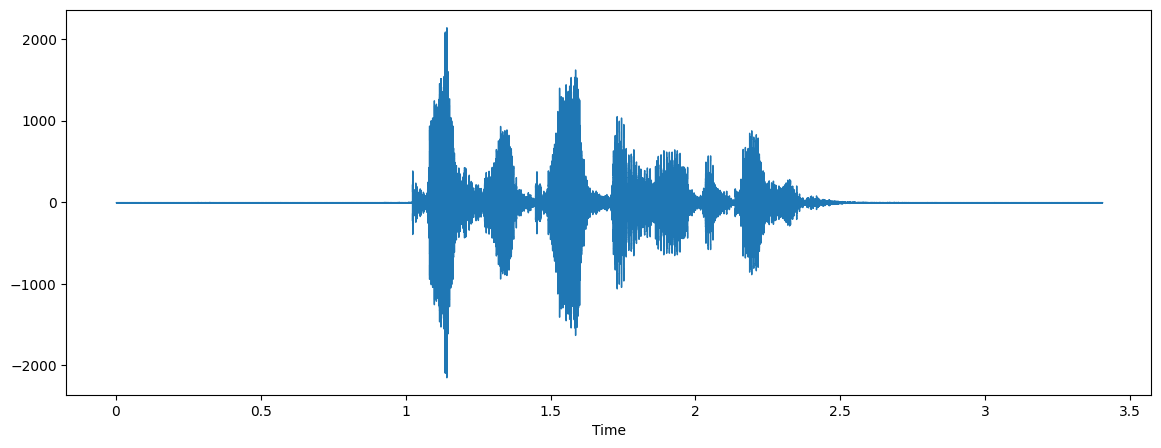

In [7]:
plt.figure(figsize=(14,5))
librosa.display.waveshow(data,sr=sample_rate)

In [8]:
display.Audio(FILE)

In [9]:
data[122400:122420]

array([], dtype=float64)

/tmp/ipykernel_68379/2709675093.py:2: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  librosa.display.specshow(sgram)


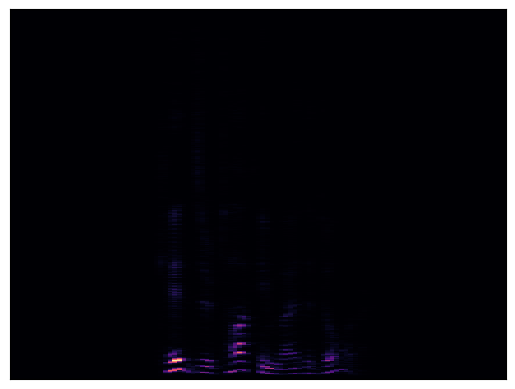

In [10]:
sgram = librosa.stft(data)
librosa.display.specshow(sgram)

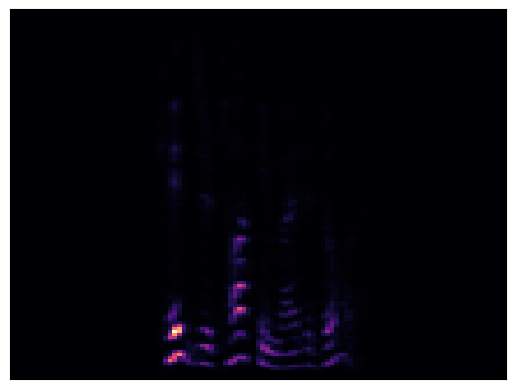

In [11]:
sgram_mag, _ = librosa.magphase(sgram)
mel_scale_sgram = librosa.feature.melspectrogram(S=sgram_mag, sr=sample_rate)
librosa.display.specshow(mel_scale_sgram)

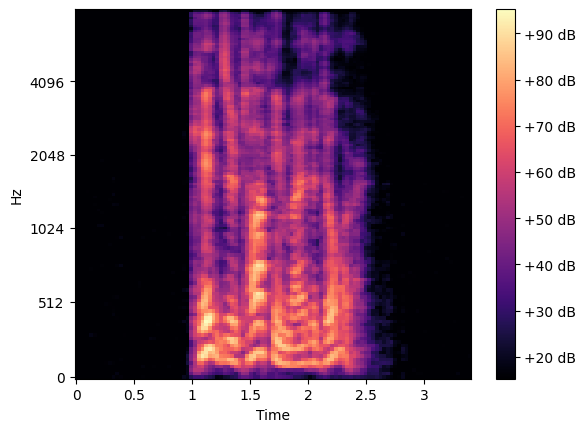

In [12]:
mel_sgram = librosa.amplitude_to_db(mel_scale_sgram, ref=np.min)
librosa.display.specshow(mel_sgram, sr=sample_rate, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')

In [13]:
mel_sgram[1,:]

array([15.26189458, 15.26189458, 15.26189458, 15.26189458, 15.26189458,
       15.26189458, 15.26189458, 15.26189458, 15.26189458, 15.26189458,
       15.50939493, 17.80986721, 15.52259603, 15.26189458, 15.26189458,
       15.26189458, 15.26189458, 15.26189458, 15.26189458, 15.26189458,
       15.26189458, 15.27668901, 15.26189458, 15.26189458, 15.26189458,
       15.26189458, 15.26189458, 15.26189458, 15.26189458, 15.49689531,
       19.43733934, 39.01940017, 48.21337356, 48.95462015, 41.55620794,
       41.50072581, 36.2325287 , 32.78530778, 31.16849791, 31.99846876,
       36.46875863, 35.10496898, 32.95875605, 29.18939091, 39.36931201,
       48.35125049, 47.05810204, 36.63564002, 31.54770882, 36.6055927 ,
       42.12490554, 42.01084385, 34.1624103 , 33.856569  , 37.40660815,
       33.23912836, 31.60393704, 27.8520892 , 29.84062794, 32.25050768,
       31.6686598 , 31.39876993, 28.77092507, 29.92253325, 32.29109316,
       36.61841579, 42.63595367, 46.11490324, 41.68197164, 37.14

MFCC is of type <class 'numpy.ndarray'> with shape (20, 107)


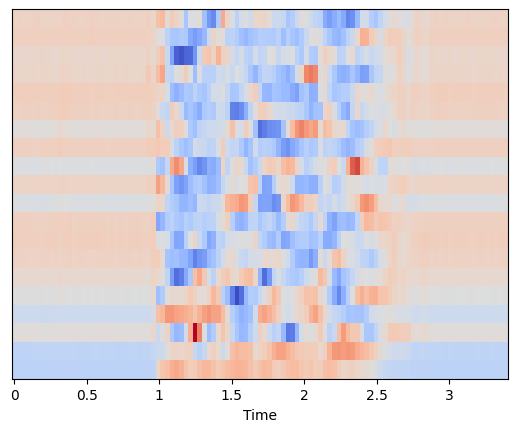

In [14]:
import sklearn
mfcc = librosa.feature.mfcc(y=data, sr=sample_rate)
mfcc = sklearn.preprocessing.scale(mfcc,axis=1)
librosa.display.specshow(mfcc, sr=sample_rate, x_axis='time')
print (f'MFCC is of type {type(mfcc)} with shape {mfcc.shape}')

In [ ]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory='datasets',
    batch_size=64,
    validation_split=0.2,
    seed=0,
    output_sequence_length=None,
    subset='both')

label_names = np.array(train_ds.class_names)
print()
print("label names:", label_names)
